In [2]:
import awkward as ak
import matplotlib.pyplot as plt


In [3]:
sig = ak.from_parquet("/home/laurits/0406_ntuples/z_train.parquet")
bkg = ak.from_parquet("/home/laurits/0406_ntuples/qq_train.parquet")

In [20]:

import os
import sys
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from pathlib import Path
from docopt import docopt

sys.path.insert(0, "/home/laurits/ml-tau/ml-tau-data/ntupelizer/tools")
import general as g


def mean_weight_per_bin(values, weights, bins):
    bin_indices = np.digitize(values, bins) - 1
    mean_w = np.array([
        weights[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan
        for i in range(len(bins))
    ])
    return mean_w


def plot_mean_weight(sig_vals, bkg_vals, sig_w, bkg_w, bins, xlabel):
    sig_mean = mean_weight_per_bin(sig_vals, sig_w, bins)
    bkg_mean = mean_weight_per_bin(bkg_vals, bkg_w, bins)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(bins, sig_mean, label="Signal", color="red")
    ax.plot(bins, bkg_mean, label="Background", color="blue")
    ax.axhline(1.0, color="gray", linestyle="--", label="w=1")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean weight per bin")
    ax.legend()
    plt.tight_layout()
    plt.show()





In [21]:
sig_data = sig
bkg_data = bkg

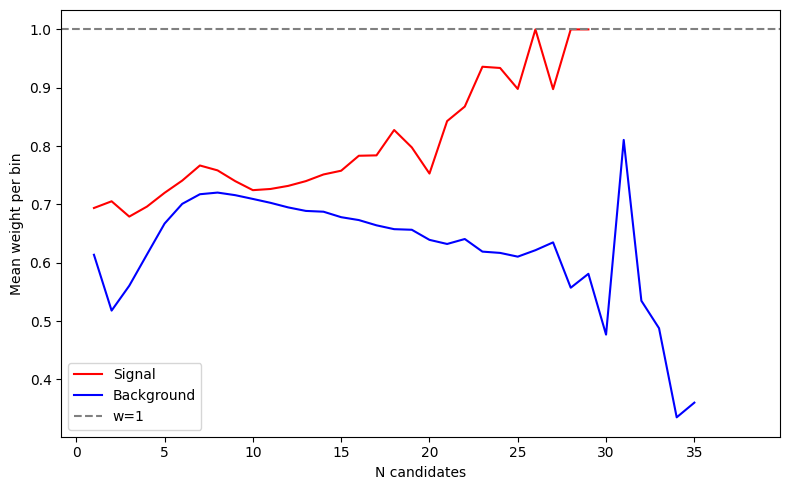

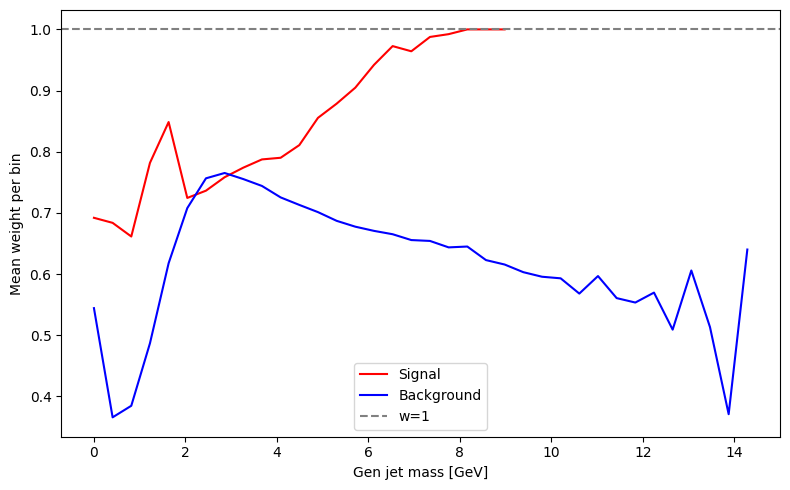

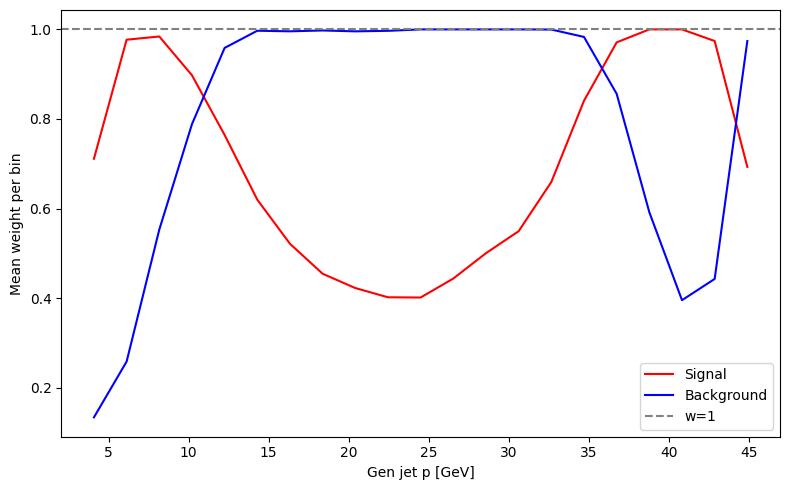

Signal   weight: mean=0.7005, std=0.2631
Background weight: mean=0.6876, std=0.2867


In [22]:
    sig_w = ak.to_numpy(sig_data["cls_weight"]).astype(float)
    bkg_w = ak.to_numpy(bkg_data["cls_weight"]).astype(float)

    # ── n_cands ───────────────────────────────────────────────────────────────
    sig_ncands = ak.to_numpy(ak.num(sig_data["reco_cand_p4s"])).astype(float)
    bkg_ncands = ak.to_numpy(ak.num(bkg_data["reco_cand_p4s"])).astype(float)

    plot_mean_weight(
        sig_ncands, bkg_ncands, sig_w, bkg_w,
        bins=np.arange(0, 51, 1),
        xlabel="N candidates",
    )

    # ── jet mass ──────────────────────────────────────────────────────────────
    sig_mass = ak.to_numpy(g.reinitialize_p4(sig_data["gen_jet_p4"]).mass)
    bkg_mass = ak.to_numpy(g.reinitialize_p4(bkg_data["gen_jet_p4"]).mass)

    plot_mean_weight(
        sig_mass, bkg_mass, sig_w, bkg_w,
        bins=np.linspace(0, 20, 50),
        xlabel="Gen jet mass [GeV]",
    )

    # ── jet p ─────────────────────────────────────────────────────────────────
    sig_p = ak.to_numpy(g.reinitialize_p4(sig_data["gen_jet_p4"]).p)
    bkg_p = ak.to_numpy(g.reinitialize_p4(bkg_data["gen_jet_p4"]).p)

    plot_mean_weight(
        sig_p, bkg_p, sig_w, bkg_w,
        bins=np.linspace(0, 100, 50),
        xlabel="Gen jet p [GeV]",
    )

    print(f"Signal   weight: mean={sig_w.mean():.4f}, std={sig_w.std():.4f}")
    print(f"Background weight: mean={bkg_w.mean():.4f}, std={bkg_w.std():.4f}")

In [23]:
sig.fields

['reco_jet_p4',
 'reco_cand_p4s',
 'reco_cand_charges',
 'reco_cand_pdgs',
 'reco_cand_dz',
 'reco_cand_dz_error',
 'reco_cand_dxy',
 'reco_cand_dxy_error',
 'gen_jet_p4',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_charge',
 'gen_jet_tau_p4',
 'cls_weight']